# Part 0
- Data cleaning.
- Data transformation.
- The above are achieved by converting most data types to numerical .
- Also cleaning data is very important because the models expect numerical data not strings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

URL = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(URL)
print(df.shape)
print(df.dtypes)

(1000, 16)
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [2]:
df_clean = df.copy()

df_clean['Runtime'] = pd.to_numeric(
    df_clean['Runtime'].str.replace(' min', '', regex=False), errors='coerce')
df_clean['Gross'] = pd.to_numeric(
    df_clean['Gross'].str.replace(',', '', regex=False), errors='coerce')
df_clean['Released_Year'] = pd.to_numeric(
    df_clean['Released_Year'], errors='coerce')

df_clean = df_clean.dropna(subset=['Released_Year'])
df_clean['Released_Year'] = df_clean['Released_Year'].astype(int)

missing = df_clean.isnull().sum()
print(missing[missing > 0])

Certificate    101
Meta_score     157
Gross          169
dtype: int64


**Feature engineering**
- we map the certificates to just 4 values
- create Num_genres and one shot encode genres as well
- one shot encode the 4 certificates we created
- also add director appearences and no_of_prolific_actors and max_actor_count
- then we drop the columns we do not need 

In [3]:
def transform_certificate_genre_star_director(df_clean) :
    cert_map = {
        'G': 'Universal', 'U': 'Universal', 'PG': 'Universal',
        'GP': 'Universal', 'TV-PG': 'Universal', 'Passed': 'Universal',
        'Approved': 'Universal', 'UA': 'UnderSupervision',
        'U/A': 'UnderSupervision', 'PG-13': 'UnderSupervision',
        'TV-14': 'UnderSupervision', 'A': 'Adult', 'R': 'Adult',
        'TV-MA': 'Adult', 'Unrated': 'Adult', '16': 'Adult',
        'Unknown': 'Unknown'
    }
    df_clean['Certificate'] = df_clean['Certificate'].map(cert_map).fillna('Unknown')

    from sklearn.preprocessing import MultiLabelBinarizer

    df_clean['Genre_List'] = (df_clean['Genre']
        .str.split(',')
        .apply(lambda x: [g.strip() for g in x]))
    
    df_clean['Num_Genres'] = df_clean['Genre_List'].apply(len)

    mlb = MultiLabelBinarizer()
    genre_encoded = pd.DataFrame(
        mlb.fit_transform(df_clean['Genre_List']),
        columns=[f'Genre_{g}' for g in mlb.classes_],
        index=df_clean.index
    )

    cert_encoded = pd.get_dummies(df_clean['Certificate'], prefix='Cert')

    director_counts = df_clean['Director'].value_counts()
    df_clean['Director_appearences'] = df_clean['Director'].map(
        lambda x: director_counts[x] if x in director_counts else 0)

    all_actors = pd.concat([df_clean['Star1'], df_clean['Star2'],
                            df_clean['Star3'], df_clean['Star4']])
    actor_counts = all_actors.value_counts()

    def nr_of_prolific_actor(row):
        count = 0
        for col in ['Star1', 'Star2', 'Star3', 'Star4']:
            if actor_counts.get(row[col], 0) >= 3:
                count += 1
        return count
    
    def max_actor_count(row):
        return max(actor_counts.get(row[col], 0) for col in ['Star1', 'Star2', 'Star3', 'Star4'])

    df_clean['Max_Actor_Count'] = df_clean.apply(max_actor_count, axis=1)

    df_clean['Nr_of_Prolific_Actors'] = df_clean.apply(nr_of_prolific_actor, axis=1)

    df_clean = pd.concat([df_clean, genre_encoded, cert_encoded], axis=1)

    cols_to_drop = ['Poster_Link', 'Overview', 'Genre', 'Genre_List',
                    'Certificate', 'Director', 'Star1', 'Star2', 'Star3', 'Star4',
                    'Series_Title']
    df_clean = df_clean.drop(columns=cols_to_drop)

    print(f"Shape: {df_clean.shape}")
    print(f"Remaining NaNs: {df_clean.isnull().sum().sum()}")
    print(df_clean.dtypes)
    
    return df_clean
    
df_clean = transform_certificate_genre_star_director(df_clean)

Shape: (999, 35)
Remaining NaNs: 326
Released_Year              int64
Runtime                    int64
IMDB_Rating              float64
Meta_score               float64
No_of_Votes                int64
Gross                    float64
Num_Genres                 int64
Director_appearences       int64
Max_Actor_Count            int64
Nr_of_Prolific_Actors      int64
Genre_Action               int64
Genre_Adventure            int64
Genre_Animation            int64
Genre_Biography            int64
Genre_Comedy               int64
Genre_Crime                int64
Genre_Drama                int64
Genre_Family               int64
Genre_Fantasy              int64
Genre_Film-Noir            int64
Genre_History              int64
Genre_Horror               int64
Genre_Music                int64
Genre_Musical              int64
Genre_Mystery              int64
Genre_Romance              int64
Genre_Sci-Fi               int64
Genre_Sport                int64
Genre_Thriller             int64
Genre_

**Convert bool to int**

In [4]:
def fix_from_bool_to_int (df_clean) :
    
    cert_cols = [col for col in df_clean.columns if col.startswith('Cert_')]
    df_clean[cert_cols] = df_clean[cert_cols].astype(int)

    print(df_clean[cert_cols].dtypes)
    return df_clean

df_clean = fix_from_bool_to_int(df_clean)

Cert_Adult               int64
Cert_UnderSupervision    int64
Cert_Universal           int64
Cert_Unknown             int64
dtype: object


**Managing missing values**
- instead of filling the NaNs with mean or median we decided to use knnimputer to compute in the n-dimension the distance from
- the other instances and take for the missing columns value the mean of the top k closest entities
- this has proven to yield better results than filling with mean/median.

In [5]:

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
def fix_missing_values_with_knn (df_clean) :

    cols_to_impute = df_clean.columns.tolist()

    # scaler = StandardScaler()
    # scaled_data = scaler.fit_transform(df_clean[cols_to_impute])

    imputer = KNNImputer(n_neighbors=5)
    imputed_scaled = imputer.fit_transform(df_clean[cols_to_impute])

    # imputed_original = scaler.inverse_transform(imputed_scaled)
    df_clean[cols_to_impute] = imputed_scaled
    
    return df_clean

df_clean = fix_missing_values_with_knn(df_clean)

# **Part1** K-Means .
- we choose the most important columns to test on based on previous homeworks
- we use the elbow method , silhoutte score to determine the optimal number of clusters
- we fit the k-means using the best result from the silhoutte score since it has proven in our tests to be more reliable,
observation from elbow method that more clusters might actually overfit and not help
- we also do pca to visualize clusters in 2d
- interpretation of results at the end
- also we log the votes and gross since they are skewed 

In [6]:
from sklearn.preprocessing import StandardScaler

more_important_columns = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 
                          'No_of_Votes', 'Gross', 'Num_Genres', 'Director_appearences', 'Max_Actor_Count', 
                          'Nr_of_Prolific_Actors']

df_clean['Log_Votes'] = np.log1p(df_clean['No_of_Votes'])
df_clean['Log_Gross'] = np.log1p(df_clean['Gross'])


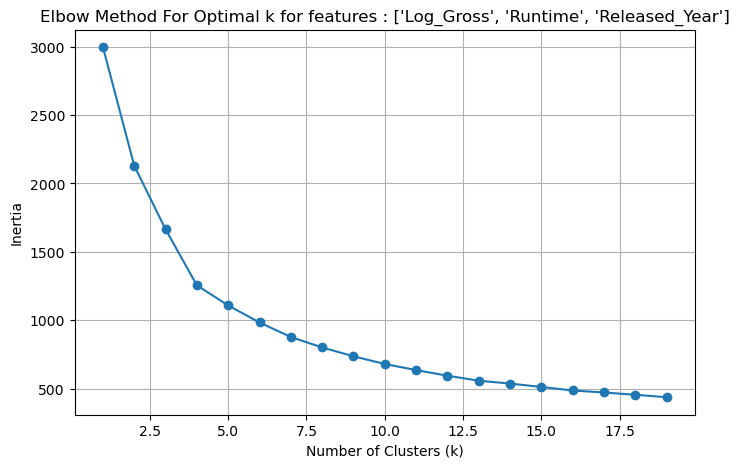

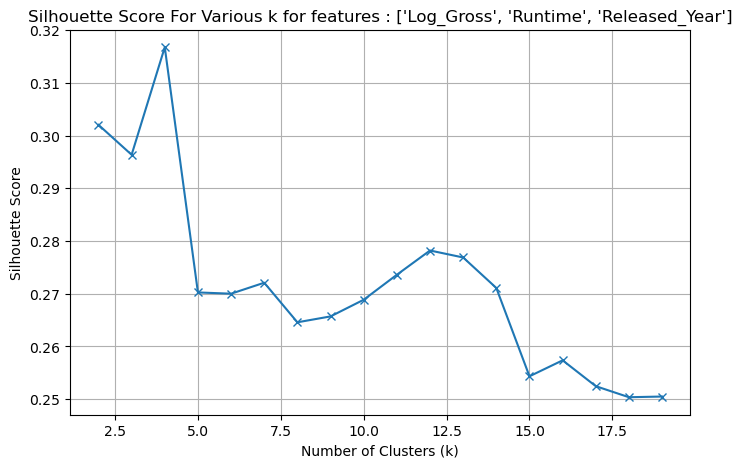

Best k: 4 (Silhouette Score: 0.3168)


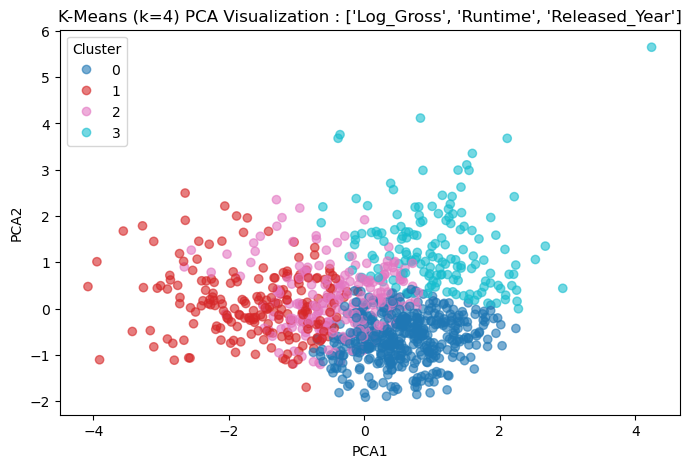


Cluster Profiles (mean feature values):
         Log_Gross  Runtime  Released_Year
Cluster                                   
0            17.98   117.49        2001.08
1            15.14   106.53        1954.84
2            14.05   114.10        2004.97
3            16.71   171.54        1993.46

Cluster sizes:
Cluster
0    419
1    206
2    219
3    155
Name: count, dtype: int64


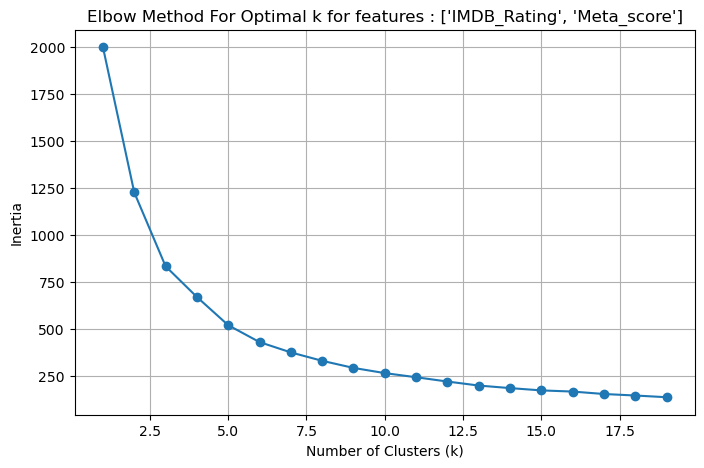

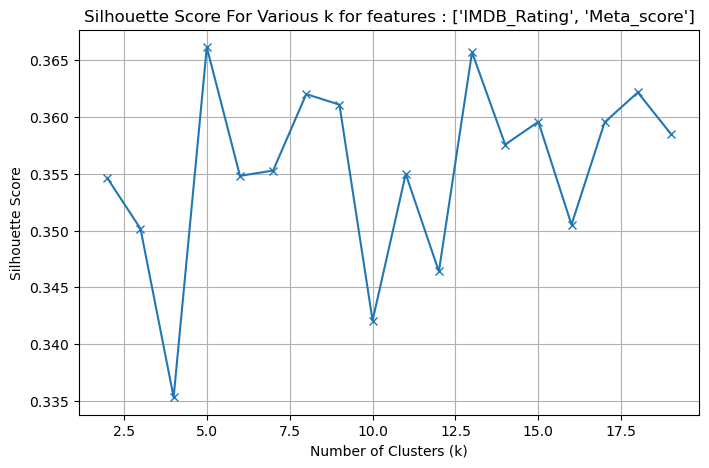

Best k: 5 (Silhouette Score: 0.3662)


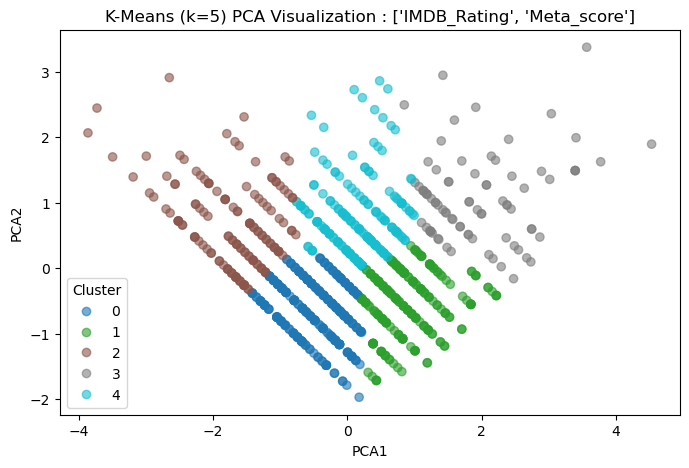


Cluster Profiles (mean feature values):
         IMDB_Rating  Meta_score
Cluster                         
0               7.73       79.60
1               8.03       89.91
2               7.74       59.36
3               8.54       85.75
4               8.13       73.67

Cluster sizes:
Cluster
0    330
1    245
2    148
3     82
4    194
Name: count, dtype: int64


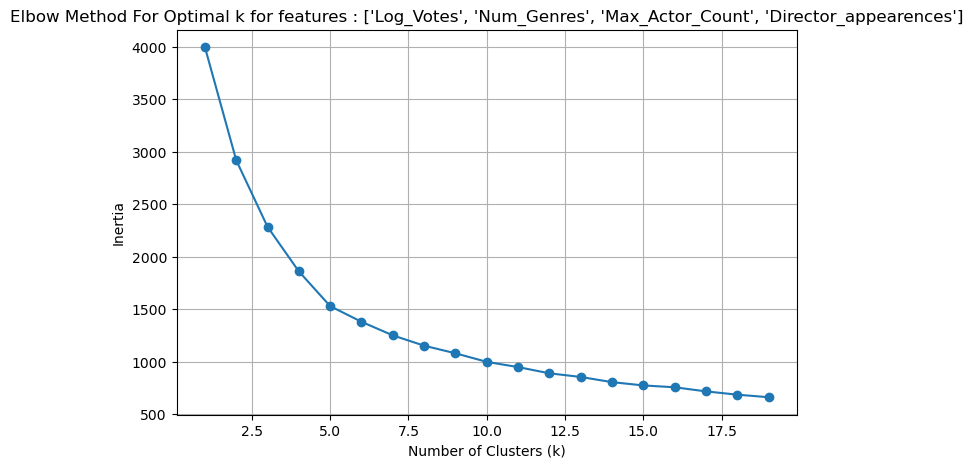

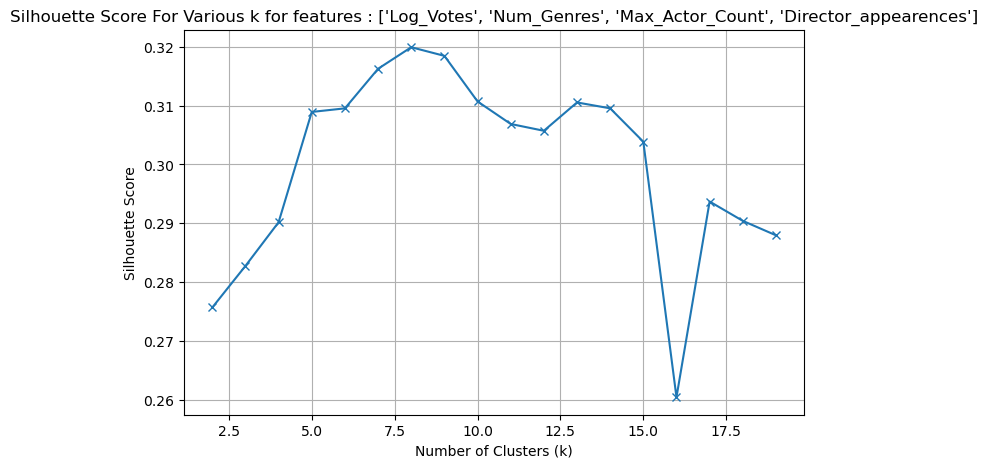

Best k: 8 (Silhouette Score: 0.3199)


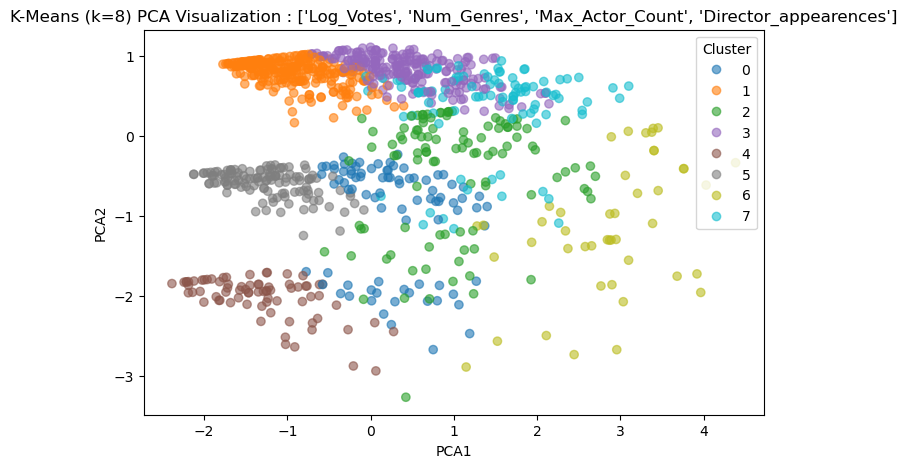


Cluster Profiles (mean feature values):
         Log_Votes  Num_Genres  Max_Actor_Count  Director_appearences
Cluster                                                              
0            12.94        1.72             4.86                  2.81
1            10.98        3.00             2.86                  1.93
2            11.94        2.74             4.63                  9.45
3            12.90        3.00             4.27                  2.39
4            11.05        1.00             3.01                  2.48
5            10.95        2.00             2.57                  2.05
6            13.41        2.22            12.16                  8.60
7            12.42        2.86            10.98                  2.89

Cluster sizes:
Cluster
0     85
1    256
2    105
3    213
4     75
5    125
6     45
7     95
Name: count, dtype: int64


In [10]:
def analyze_clustering(df, features_input):
    
    features_for_clustering = df[features_input]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_for_clustering)

    inertia = []
    k_range = range(1, 20)
    for k in k_range:
        kmeans = KMeans(n_init=10, n_clusters=k, random_state=23)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia, marker='o')
    plt.title(f'Elbow Method For Optimal k for features : {features_input}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.grid()
    plt.show()

    silhouette_scores = []
    k_vals = range(2, 20)
    for k in k_vals:
        kmeans = KMeans(n_init=10, n_clusters=k, random_state=23)
        labels = kmeans.fit_predict(X_scaled)
        silhouette_scores.append(silhouette_score(X_scaled, labels))

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, silhouette_scores, marker='x')
    plt.title(f'Silhouette Score For Various k for features : {features_input}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid()
    plt.show()

    best_k = list(k_vals)[np.argmax(silhouette_scores)]
    print(f"Best k: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

    kmeans_best = KMeans(n_init=10, n_clusters=best_k, random_state=23)
    cluster_labels = kmeans_best.fit_predict(X_scaled)

    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(components[:, 0], components[:, 1], 
                          c=cluster_labels, cmap='tab10', alpha=0.6)
    plt.legend(*scatter.legend_elements(), title='Cluster')
    plt.title(f"K-Means (k={best_k}) PCA Visualization : {features_input}")
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.show()
     
    df_temp = df[features_input].copy()
    df_temp['Cluster'] = cluster_labels

    cluster_means = df_temp.groupby('Cluster')[features_input].mean()
    print("\nCluster Profiles (mean feature values):")
    print(cluster_means.round(2).to_string())
    print(f"\nCluster sizes:")
    print(df_temp['Cluster'].value_counts().sort_index())
    
    
analyze_clustering(df_clean, ['Log_Gross', 'Runtime', 'Released_Year'])
analyze_clustering(df_clean, ['IMDB_Rating', 'Meta_score'])
analyze_clustering(df_clean, ['Log_Votes', 'Num_Genres', 'Max_Actor_Count', 'Director_appearences'])

**Obs**
- Financial metrics :
    + cluster 0 (modern comercial hits)
    + cluster 1 (classic movies)
    + cluster 2 (recent low-earning movies)
    + cluster 3 (longest running movies also 90s)

- Quality metrics (here is a like a tier list based on score(critics + fans)):
    + cluster 0 (above average all arounf)
    + cluster 1 (loved by critics)
    + cluster 2 (not very appreciated by critics)
    + cluster 3 (best movies from all point of view (fans or criticcs))
    + cluster 4 (very similar to cluster 0 but slight difference from critics to fans)

- Popularity matrix (here it is hard to determine what really is the difference between clusters):
    + clusters 0, 3 (popular movies but not such renowned actors)
    + clusters 1, 5 (average nothing special)
    + cluster 2 (most appearences directors)
    + cluster 4 (niche movies low in popularity and genre)
    + cluster 6 (most populat actor and good director)
    + cluster 7 (similar to 6 less populat directors)

 # Part2
- we create the Is_Highly_Rated label
- we filter the features even more based on previous results
- we test for different combinations of selected features to see which score best
- once we get the best combination we also do the interpretation of the coefficients of the model to obs
which feat influences the result the most


In [39]:
df_clean['Is_Highly_Rated'] = (df_clean['IMDB_Rating'] >= 8.0).astype(int)
df_clean['Is_Highly_Rated'].value_counts()

Is_Highly_Rated
0    536
1    463
Name: count, dtype: int64

In [ ]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler

features_for_lr = ['Log_Gross', 'Runtime', 'Released_Year', 
                   'Log_Votes', 'Num_Genres', 'Max_Actor_Count',
                   'Director_appearences', 'Nr_of_Prolific_Actors', 'Meta_score']

results = []
for i in range(2, len(features_for_lr)):
    for combo in combinations(features_for_lr, i):
        X = df_clean[list(combo)]
        y = df_clean['Is_Highly_Rated']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = LogisticRegression(max_iter=100, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        results.append({
            'features': combo,
            'n_features': i,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print(results_df.head(15).to_string(index=False))

                                                                                                                   features  n_features  accuracy  precision   recall       f1
                              (Log_Gross, Runtime, Released_Year, Log_Votes, Num_Genres, Nr_of_Prolific_Actors, Meta_score)           7     0.755   0.800000 0.615385 0.695652
        (Log_Gross, Runtime, Released_Year, Log_Votes, Num_Genres, Director_appearences, Nr_of_Prolific_Actors, Meta_score)           8     0.755   0.800000 0.615385 0.695652
             (Log_Gross, Runtime, Released_Year, Log_Votes, Num_Genres, Max_Actor_Count, Nr_of_Prolific_Actors, Meta_score)           8     0.750   0.797101 0.604396 0.687500
                         (Log_Gross, Runtime, Released_Year, Log_Votes, Max_Actor_Count, Nr_of_Prolific_Actors, Meta_score)           7     0.750   0.797101 0.604396 0.687500
   (Log_Gross, Runtime, Released_Year, Log_Votes, Max_Actor_Count, Director_appearences, Nr_of_Prolific_Actors, Meta_score)  

In [46]:
best_features = ['Log_Gross', 'Runtime', 'Released_Year', 
                 'Log_Votes', 'Num_Genres', 'Nr_of_Prolific_Actors', 'Meta_score']

X = df_clean[best_features]
y = df_clean['Is_Highly_Rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

coef_df = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(f"\nFeature Coefficients :")
print(coef_df.to_string(index=False))

Accuracy:  0.7550
Precision: 0.8000
Recall:    0.6154
F1 Score:  0.6957

Confusion Matrix:
[[95 14]
 [35 56]]

Feature Coefficients :
              Feature  Coefficient
            Log_Votes     1.103227
            Log_Gross    -0.676901
              Runtime     0.603883
        Released_Year    -0.451273
           Meta_score     0.430536
Nr_of_Prolific_Actors    -0.224244
           Num_Genres    -0.141416


**Obs**
- as can be seen the model can more accurately predict lower than 8.0 rating movies compared to the higher ones
- log_votes highest coefficient (good movies get more votes)
- log_gross reveals that high office box movies tend to not be as appreciated as more neiche ones
- released_year reveals that older movies tend to be better rated
- meta_score is interesting because it reveals that fans generally agree with critics but not fully
- also features such as log_gross , nr_of_prolific actors are negative suggesting that commercial does not always makes for qualitative movies

# Part 3 Insights from Part1 and Part2 + improvemennts


**Insights**
- quality metrics produced cleanest groups suggesting that it is good splitting the movies for classification based on rating
- classification hinted at the same as clustering (high gross movies (especially newer ones) are in different categories than older aprreciated movies), suggested by the clustering results as seen and the negative coefficient of log_gross meaning commercial succes goes against high imdb rating or higher because we are talking about the best 1000 .
- the popularity group was also meaningfull in the clustering and also shown in high coefficine of log_votes
- also the movies with which our classification struggles which is (movies above 8.0 rating) (also cluster 3 from quality metrics just 82 movies) gets us a big part I think of the 35 negatives as it cannot differentiate between above average and likes by critics

**Improvements**
- the dataset itself is a limiting factor (very few entities just 1000) and features not descriptive enough
- maybe working with the top 2000 imdb rating movies might help
- maybe not considering very niche movies might help
- also maybe usage of different classification models might yield different results(better or worse)
- features like oscar results, directors previous recors, might help
- these could be extracted via a web scraper and data extracted processed and curated
- also getting more signal out of genre and certificate in a way (if possible) might also help a lot
- the feat that is in the original dataset and not used at all is overview it might reveal a great amount of information
as things like emotion, directm opinionm through speech.
- also I dont agree that kids movies such as lion-king be included in the same dataset as inglorious basters for example,  I think they should have never been in the same discussion from the begining
- my main improvements are all related to the original dataset and how it is processed mainly (the data processing pipeline mainly)
